# Proyecto: Clasificador de Letras ASL

Se seleccionó una submuestra del dataset original de Kaggle para este laboratorio. Tomé 600 imágenes por cada clase, lo cual es suficiente para capturar la variabilidad de los datos sin sobrepasar las limitaciones de cómputo y tiempo del entorno de trabajo.

## Ejemplos de imágenes

A continuación muestro ejemplos de cinco letras distintas del alfabeto ASL para observar la variabilidad de las imágenes dentro de una misma clase.

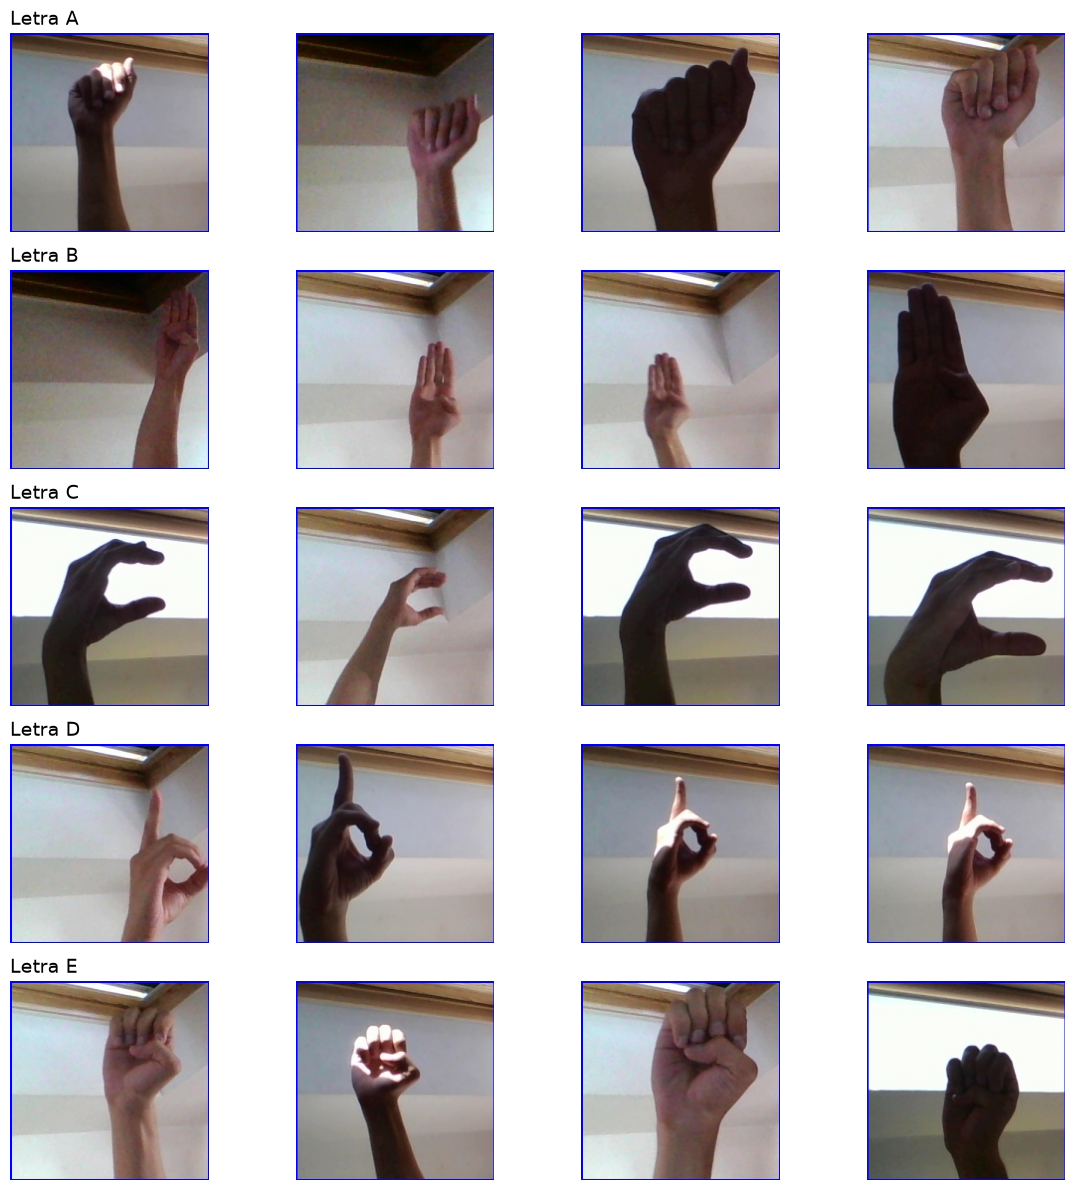

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

letras = ['A', 'B', 'C', 'D', 'E']
muestras_por_letra = 4
base_path = '../data'

fig, axes = plt.subplots(len(letras), muestras_por_letra, figsize=(12, 12))

for i, letra in enumerate(letras):
    letra_path = os.path.join(base_path, letra)
    if os.path.exists(letra_path):
        imagenes = os.listdir(letra_path)[:muestras_por_letra]
        for j, img_name in enumerate(imagenes):
            img_path = os.path.join(letra_path, img_name)
            img = mpimg.imread(img_path)
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(f'Letra {letra}', fontsize=14, loc='left')

plt.tight_layout()
plt.show()

Noté que dentro de cada letra existen cambios importantes en la iluminación y el tipo de fondo. También observé variaciones en la posición y el ángulo de la mano, así como la distancia de la mano a la cámara.

## Análisis exploratorio

In [2]:
from PIL import Image
import os

base_path = '../data'
clases = sorted(os.listdir(base_path))

tamaños = set()
formatos = set()
modos = set()

for clase in clases:
    clase_path = os.path.join(base_path, clase)
    for nombre_img in os.listdir(clase_path)[:5]:
        img = Image.open(os.path.join(clase_path, nombre_img))
        tamaños.add(img.size)
        formatos.add(img.format)
        modos.add(img.mode)

print('Dimensiones encontradas:', tamaños)
print('Formatos encontrados:', formatos)
print('Modos de color encontrados:', modos)

Dimensiones encontradas: {(200, 200)}
Formatos encontrados: {'JPEG'}
Modos de color encontrados: {'RGB'}


Revisé una muestra de imágenes de cada una de las 29 clases y todas tienen la misma resolución de 200x200 píxeles, están en formato JPEG y son a color con los tres canales RGB. No encontré imágenes en escala de grises ni con dimensiones distintas dentro de la submuestra.

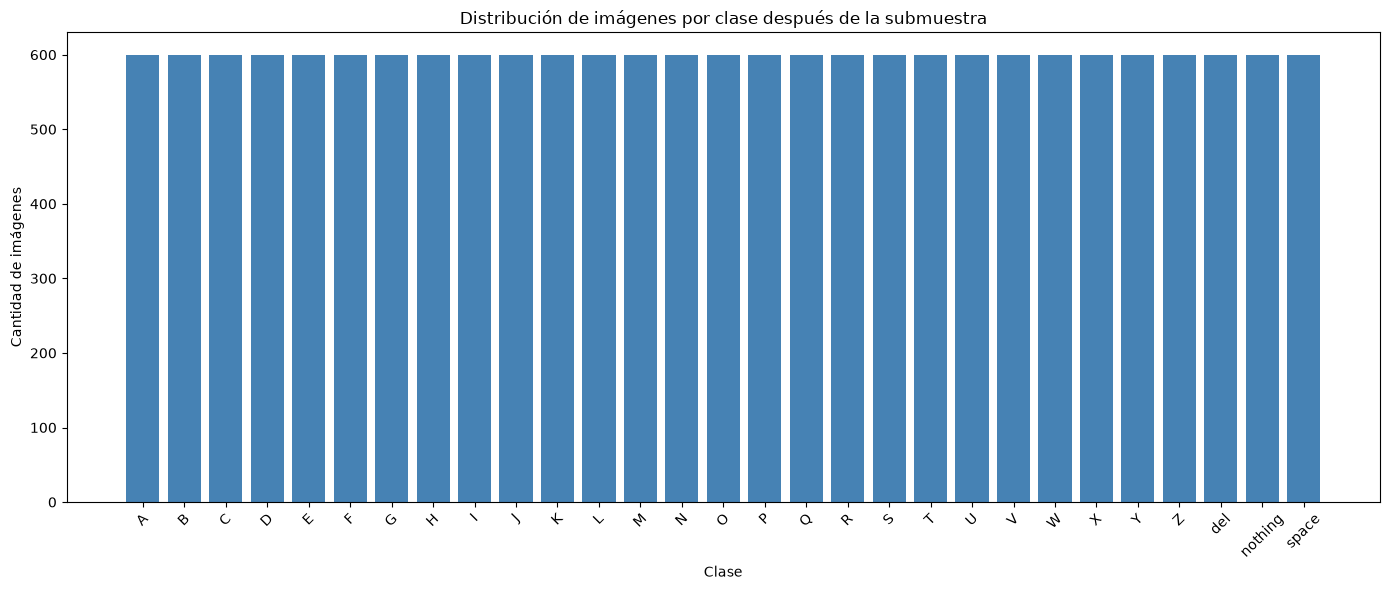

Mínimo de imágenes en una clase: 600
Máximo de imágenes en una clase: 600


In [3]:
conteo_clases = {clase: len(os.listdir(os.path.join(base_path, clase))) for clase in clases}

plt.figure(figsize=(14, 6))
plt.bar(conteo_clases.keys(), conteo_clases.values(), color='steelblue')
plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.title('Distribución de imágenes por clase después de la submuestra')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Mínimo de imágenes en una clase:', min(conteo_clases.values()))
print('Máximo de imágenes en una clase:', max(conteo_clases.values()))

Todas las 29 clases quedaron con exactamente 600 imágenes, así que el dataset original tenía suficientes imágenes disponibles por letra y la submuestra queda perfectamente balanceada.

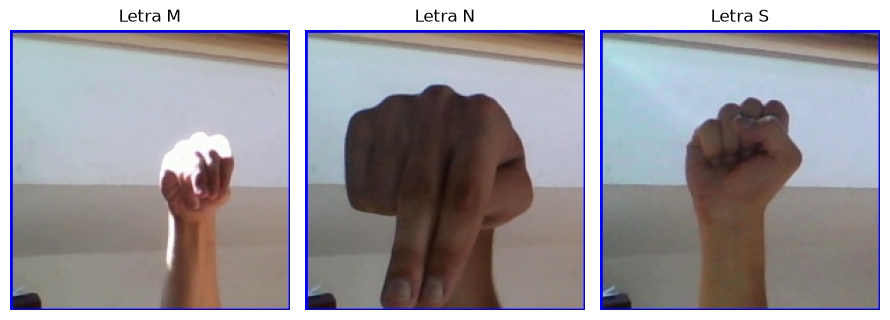

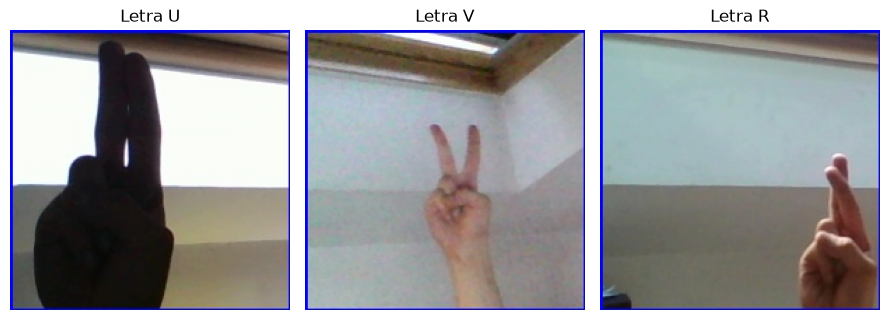

In [4]:
grupos_similares = [['M', 'N', 'S'], ['U', 'V', 'R']]

for grupo in grupos_similares:
    fig, axes = plt.subplots(1, len(grupo), figsize=(9, 4))
    for ax, letra in zip(axes, grupo):
        letra_path = os.path.join(base_path, letra)
        img_name = os.listdir(letra_path)[0]
        img = mpimg.imread(os.path.join(letra_path, img_name))
        ax.imshow(img)
        ax.set_title(f'Letra {letra}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Las letras M, N y S se parecen porque las tres se forman con el puño cerrado y el pulgar escondido debajo de los otros dedos, la diferencia entre ellas es solo la posición exacta del pulgar respecto a los dedos que lo cubren. Algo similar pasa con U, V y R, que se hacen con dos dedos extendidos y varían únicamente en si están juntos, separados o cruzados.

Para el modelo esto puede ser un problema porque son diferencias muy pequeñas en la imagen, casi a nivel de píxeles, y se pueden perder fácilmente con variaciones de ángulo, iluminación o resolución. Es probable que estas letras generen más confusión en la clasificación que otras con formas de mano claramente distintas.

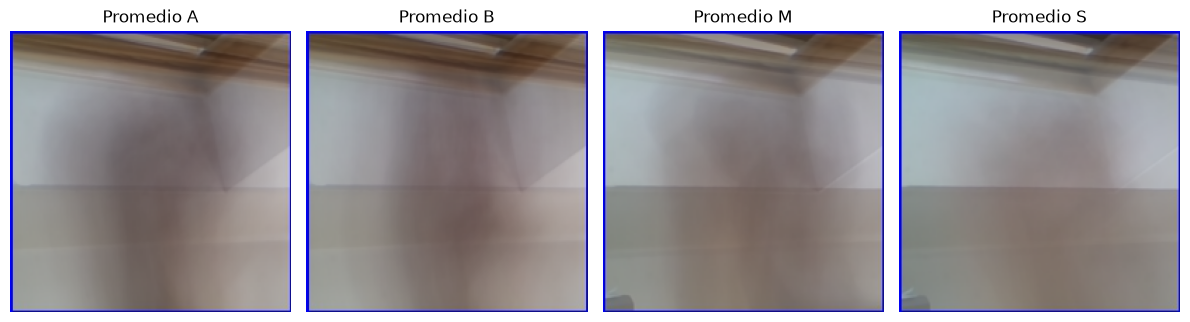

In [5]:
import numpy as np

clases_promedio = ['A', 'B', 'M', 'S']

fig, axes = plt.subplots(1, len(clases_promedio), figsize=(12, 4))

for ax, clase in zip(axes, clases_promedio):
    clase_path = os.path.join(base_path, clase)
    imagenes = os.listdir(clase_path)
    acumulador = np.zeros((200, 200, 3), dtype=np.float64)
    for nombre_img in imagenes:
        img = np.array(Image.open(os.path.join(clase_path, nombre_img)))
        acumulador += img
    promedio = (acumulador / len(imagenes)).astype(np.uint8)
    ax.imshow(promedio)
    ax.set_title(f'Promedio {clase}')
    ax.axis('off')

plt.tight_layout()
plt.show()

La imagen promedio se construye sumando pixel por pixel todas las fotos de una clase y dividiendo entre el total de imágenes. Si la seña se hace siempre en una posición y encuadre parecidos, el promedio sale nítido, con la forma de la mano reconocible. Si hay mucha variación de posición dentro de la clase, el promedio se ve borroso porque los bordes de la mano caen en lugares distintos de cada foto.

Lo que salió fue justamente eso último en las cuatro clases. El fondo, la pared y el borde de la puerta se ven casi idénticos entre A, B, M y S, lo que confirma que las fotos se tomaron con la cámara fija en la misma posición. Pero la mano en sí se pierde en una mancha difusa color piel en el centro de la imagen, sin bordes definidos, y esto pasa igual de fuerte en las cuatro letras, no solo en el grupo M y S que ya había marcado como confuso. Esto me dice que promediar pixeles crudos no sirve para distinguir señas, porque la posición de la mano varía lo suficiente dentro de cada clase como para que el promedio no conserve la forma. Confirma que el modelo va a necesitar aprender patrones espaciales locales en vez de depender de estadísticas simples de pixel.

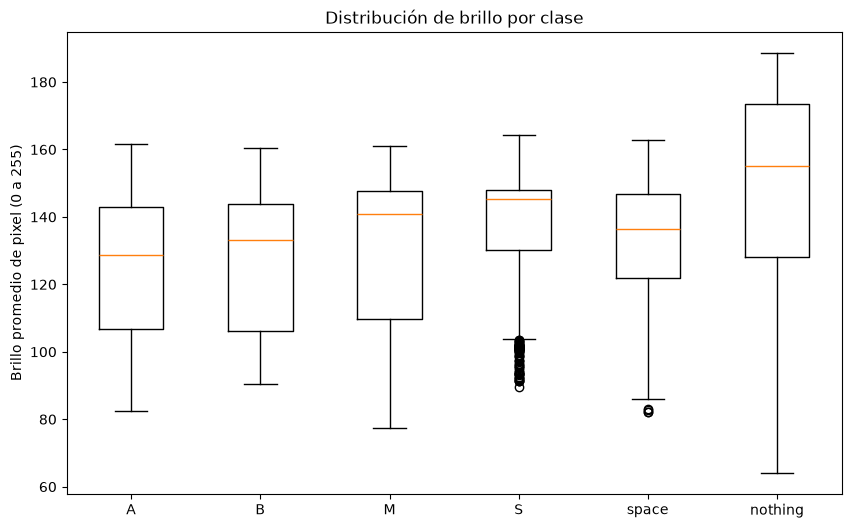

A: media=126.2, desviación=20.4
B: media=127.6, desviación=20.6
M: media=130.8, desviación=20.4
S: media=136.8, desviación=18.3
space: media=131.8, desviación=18.4
nothing: media=146.9, desviación=29.5


In [6]:
clases_brillo = ['A', 'B', 'M', 'S', 'space', 'nothing']
brillo_por_clase = {}

for clase in clases_brillo:
    clase_path = os.path.join(base_path, clase)
    valores = [np.array(Image.open(os.path.join(clase_path, nombre_img))).mean()
               for nombre_img in os.listdir(clase_path)]
    brillo_por_clase[clase] = valores

plt.figure(figsize=(10, 6))
plt.boxplot(brillo_por_clase.values(), tick_labels=brillo_por_clase.keys())
plt.ylabel('Brillo promedio de pixel (0 a 255)')
plt.title('Distribución de brillo por clase')
plt.show()

for clase, valores in brillo_por_clase.items():
    valores = np.array(valores)
    print(f'{clase}: media={valores.mean():.1f}, desviación={valores.std():.1f}')

Tomé el brillo promedio de pixel de cada imagen como métrica simple y comparé su distribución entre seis clases: cuatro letras (A, B, M, S) más las clases especiales space y nothing, que no corresponden a una letra sino a espacio y ausencia de seña.

A, B, M, S y space quedan en rangos de brillo muy parecidos entre sí, con medias entre 126 y 137 y desviaciones alrededor de 18 a 20. La clase nothing es la que se distingue: su media sube a casi 147 y su desviación es bastante más alta, cerca de 30. Tiene sentido, porque nothing captura escenas sin mano en el encuadre, así que queda más expuesta a cambios de iluminación de fondo y menos cubierta por la sombra que genera la propia mano cuando está presente. Para las letras entre sí el brillo no aporta mucho para distinguirlas, porque la iluminación depende más de la sesión de captura que de la seña específica.

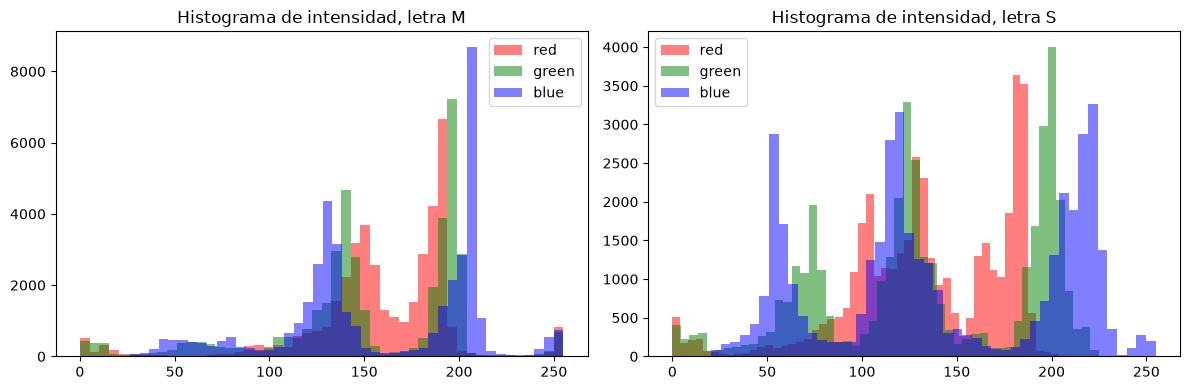

In [7]:
clases_hist = ['M', 'S']

fig, axes = plt.subplots(1, len(clases_hist), figsize=(12, 4))

for ax, clase in zip(axes, clases_hist):
    clase_path = os.path.join(base_path, clase)
    img_name = os.listdir(clase_path)[0]
    img = np.array(Image.open(os.path.join(clase_path, img_name)))
    for canal, color in enumerate(['red', 'green', 'blue']):
        ax.hist(img[:, :, canal].ravel(), bins=50, color=color, alpha=0.5, label=color)
    ax.set_title(f'Histograma de intensidad, letra {clase}')
    ax.legend()

plt.tight_layout()
plt.show()

Tomé una imagen representativa de M y otra de S y grafiqué la intensidad de cada canal de color por separado. En ambas letras los tres canales, rojo, verde y azul, siguen prácticamente la misma forma de distribución, solo desplazados un poco entre sí, lo cual es normal en piel bajo luz interior. No hay un canal que se dispare independiente de los otros.

Esto importa para la decisión de color contra escala de grises que documento más adelante en preprocesamiento, porque si los tres canales se mueven juntos, convertir a escala de grises no debería perder información relevante para distinguir la forma de la mano. La distribución en sí varía de imagen a imagen según el fondo y la sombra de esa foto puntual, como se ve en que M tiene un pico más marcado cerca de 200 y S tiene la masa más repartida entre valores bajos y altos, pero eso depende de la escena capturada en esa imagen particular, no de un patrón sistemático de la letra.

### Split de entrenamiento, validación y prueba

El set de prueba que trae Kaggle para este dataset viene con muy pocas imágenes, pensado más para una demo que para evaluar un modelo con seriedad. Por eso arme mi propio split a partir de los datos de entrenamiento que ya tengo descargados, en vez de depender de ese set oficial.

Uso una proporción 70 por ciento entrenamiento, 15 por ciento validación y 15 por ciento prueba, estratificada por clase para que las 29 letras mantengan la misma proporción en los tres conjuntos. Estratificar es importante acá porque aunque el dataset está balanceado en total, un split aleatorio simple podría dejar alguna clase con pocas imágenes en validación o prueba solo por azar, y eso haría más ruidosa la evaluación de esa clase en particular. Con 600 imágenes por clase, un 15 por ciento son 90 imágenes de prueba por letra, que me parece suficiente para medir el desempeño sin sacrificar demasiados datos de entrenamiento.

In [8]:
from sklearn.model_selection import train_test_split

archivos = []
etiquetas = []

for clase in clases:
    clase_path = os.path.join(base_path, clase)
    for nombre_img in os.listdir(clase_path):
        archivos.append(os.path.join(clase_path, nombre_img))
        etiquetas.append(clase)

archivos_train, archivos_temp, etiquetas_train, etiquetas_temp = train_test_split(
    archivos, etiquetas, test_size=0.30, stratify=etiquetas, random_state=42
)

archivos_val, archivos_test, etiquetas_val, etiquetas_test = train_test_split(
    archivos_temp, etiquetas_temp, test_size=0.50, stratify=etiquetas_temp, random_state=42
)

print('Entrenamiento:', len(archivos_train))
print('Validación:', len(archivos_val))
print('Prueba:', len(archivos_test))
print('Ejemplo de imágenes de prueba para la clase A:', etiquetas_test.count('A'))

Entrenamiento: 12180
Validación: 2610
Prueba: 2610
Ejemplo de imágenes de prueba para la clase A: 90


Con las 17400 imágenes de la submuestra, el split queda en 12180 para entrenamiento y 2610 para validación y otras 2610 para prueba, y la clase A aporta exactamente 90 imágenes al set de prueba, igual que le tocaría a cada una de las 29 clases si se reparte proporcional. Guardo las listas de rutas de archivo y etiquetas de cada conjunto para usarlas directamente cuando se arme el pipeline de entrenamiento en la entrega final.

## Preprocesamiento

Antes de entrenar cualquier modelo hay que dejar las 17400 imágenes en un formato manejable para el hardware disponible en el laboratorio. Las imágenes originales vienen a 200x200 en RGB, lo que da 40000 pixeles por canal y 120000 valores por imagen. Entrenar varias arquitecturas distintas sobre eso, incluyendo un Random Forest que no tiene forma de compartir cómputo entre pixeles como sí lo hace una convolución, sale caro en tiempo.

Por eso reduzco cada imagen a 64x64 antes de meterla a cualquier modelo. Esto deja 4096 pixeles por canal, casi 10 veces menos que el original, y sigue siendo suficiente resolución para que se distinga la forma general de la mano y la posición de los dedos, que es la información que realmente separa una letra de otra. El detalle fino que se pierde al reducir, como la textura de la piel o pequeñas variaciones de sombra, no aporta a la tarea de clasificación y hasta podría hacer que el modelo se sobreajuste a detalles irrelevantes de cada foto en particular.

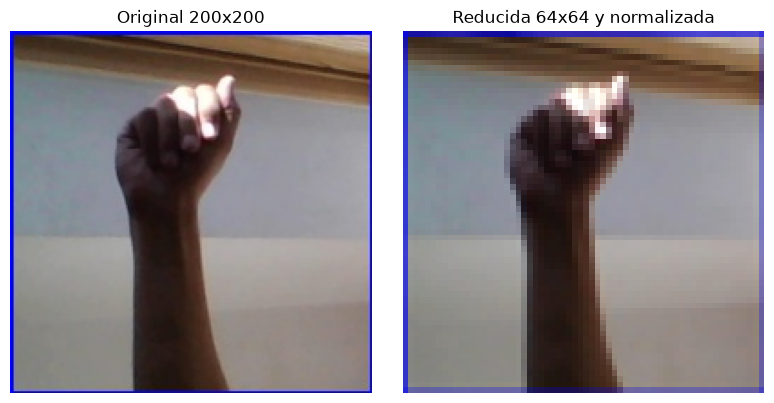

Rango de valores original: 0 a 255
Rango de valores normalizado: 0.027 a 1.0


In [9]:
TAMANO_DESTINO = (64, 64)

clase_ejemplo = 'A'
clase_ejemplo_path = os.path.join(base_path, clase_ejemplo)
img_path = os.path.join(clase_ejemplo_path, os.listdir(clase_ejemplo_path)[0])

img_original = Image.open(img_path)
img_original_array = np.array(img_original)

img_reducida = img_original.resize(TAMANO_DESTINO)
img_normalizada = np.array(img_reducida) / 255.0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_original_array)
axes[0].set_title(f'Original {img_original.size[0]}x{img_original.size[1]}')
axes[0].axis('off')
axes[1].imshow(img_normalizada)
axes[1].set_title(f'Reducida {TAMANO_DESTINO[0]}x{TAMANO_DESTINO[1]} y normalizada')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('Rango de valores original:', img_original_array.min(), 'a', img_original_array.max())
print('Rango de valores normalizado:', round(img_normalizada.min(), 3), 'a', round(img_normalizada.max(), 3))

Para la normalización divido cada pixel entre 255 para dejarlo en el rango de 0 a 1, en vez de estandarizar restando la media y dividiendo entre la desviación estándar. Con el rango 0 a 1 alcanza para este caso porque las imágenes ya vienen en una escala de iluminación bastante uniforme, según lo que vi en la distribución de brillo por clase, así que no hace falta el paso extra de calcular media y desviación por canal sobre todo el set de entrenamiento.

Decidí mantener las imágenes a color en vez de pasarlas a escala de grises. Lo pensé por el ahorro de memoria que da trabajar con un solo canal, pero en el histograma de intensidad de M y S los tres canales de color se mueven prácticamente juntos, lo que confirma que no hay señal de color que separe las letras entre sí, la información está en la forma de la mano, no en el tono. Aun así, dejo los tres canales porque el costo de cómputo ya se resolvió con la reducción a 64x64, y quitar canales en este punto sería una optimización que no hace falta para el tamaño de este laboratorio.

No aplico ningún filtro adicional de suavizado o realce de bordes. Las fotos ya vienen limpias, tomadas con una cámara fija y sin ruido visible, y el problema real que encontré en el análisis exploratorio, la confusión entre M, N, S y entre U, V, R, es de forma de mano y no de calidad de imagen, así que un filtro no ayudaría ahí. El único preprocesamiento que aplico es resize a 64x64 y la normalización a 0 y 1.

## Selección de modelos

## Plan de procesamiento de imágenes